## Notebook Purpose
This notebook profiles the generated symbolic dataset, verifies split integrity, and provides quick qualitative checks before model training.

# Dataset Analysis
Inspect generated symbolic expressions and Taylor targets.

Dataset shape: (50000, 3)
                          expression                             taylor  split
0                  3*x**2*cos(x) + x             -3*x**4/2 + 3*x**2 + x  train
1         x**2 + 2*x - 1 + exp(-2*x)       2*x**4/3 - 4*x**3/3 + 3*x**2  train
2  -3*x**4 + 2*x**3 + 3*x**2 - x - 3  -3*x**4 + 2*x**3 + 3*x**2 - x - 3  train
3       4*x**4 - 2*x**3 + x**2 - 6*x       4*x**4 - 2*x**3 + x**2 - 6*x  train
4     4*x**4 + x**3 - 5*x**2 - x - 2     4*x**4 + x**3 - 5*x**2 - x - 2  train

Split counts:
 split
train    40000
val       5000
test      5000
Name: count, dtype: int64


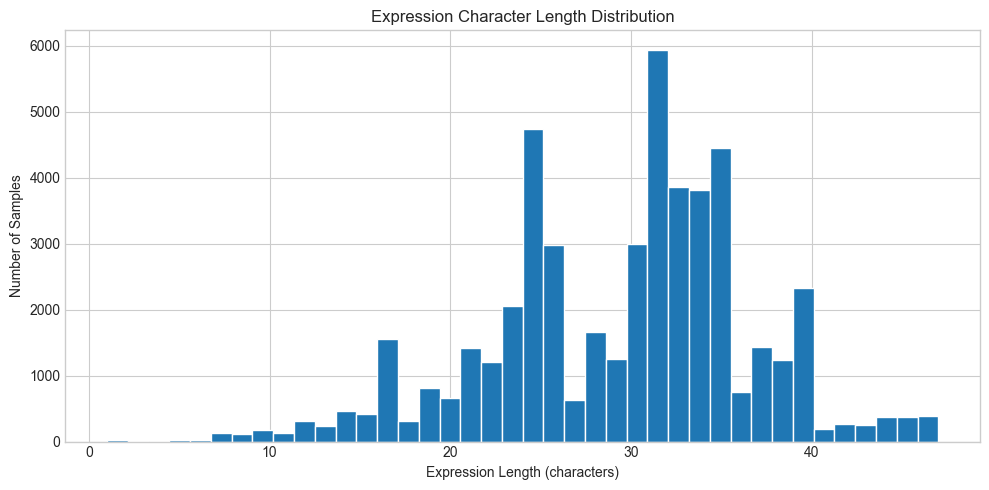

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

df = pd.read_csv("../data/taylor_dataset.csv")
print("Dataset shape:", df.shape)
print(df.head())
print("\nSplit counts:\n", df["split"].value_counts())

char_lengths = df["expression"].astype(str).str.len()
plt.figure(figsize=(10, 5))
plt.hist(char_lengths, bins=40, color="#1f77b4", edgecolor="white")
plt.title("Expression Character Length Distribution")
plt.xlabel("Expression Length (characters)")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

## Token Length Distribution
Token-level length is a better proxy for sequence modeling complexity than raw character length.

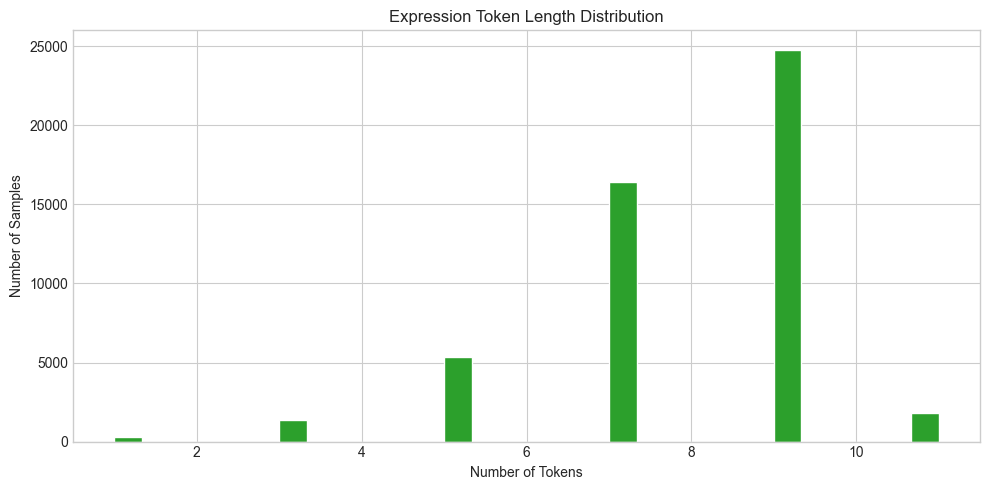

count    50000.000000
mean         7.779360
std          1.742463
min          1.000000
25%          7.000000
50%          9.000000
75%          9.000000
max         11.000000
Name: expression, dtype: float64


In [2]:
token_lengths = df["expression"].astype(str).str.split().str.len()

plt.figure(figsize=(10, 5))
plt.hist(token_lengths, bins=30, color="#2ca02c", edgecolor="white")
plt.title("Expression Token Length Distribution")
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

print(token_lengths.describe())

## Sample Expressions
A small random sample helps sanity-check expression diversity and formatting.

In [3]:
sample_n = 10
sample_df = df[["expression", "taylor", "split"]].sample(sample_n, random_state=42).reset_index(drop=True)
sample_df

,expression,taylor,split
0,-3*x**4 - 4*x**3 + 2*x**2 + 3*x + 1,-3*x**4 - 4*x**3 + 2*x**2 + 3*x + 1,train
1,5*x**4 - x**3 - 4*x**2 + 4*x + 2,5*x**4 - x**3 - 4*x**2 + 4*x + 2,train
2,(2*x + 1)*(4*x**4 + 5*x**3 - 5*x**2 + 3*x - 4),14*x**4 - 5*x**3 + x**2 - 5*x - 4,val
3,exp(5*x**3 + x**2 + 5*x + 4),1537*x**4*exp(4)/24 + 185*x**3*exp(4)/6 + 27*x...,train
4,2*x**4 + 3*x**3 - x**2 + 4*x - 4,2*x**4 + 3*x**3 - x**2 + 4*x - 4,train
5,2*x**3 + 2*x**2 - 4,2*x**3 + 2*x**2 - 4,train
6,-4*x**4 - 3*x**3 - 2*x**2 - 5*x + 5,-4*x**4 - 3*x**3 - 2*x**2 - 5*x + 5,train
7,3*x**3 + 2*x**2 + 4*x + 2,3*x**3 + 2*x**2 + 4*x + 2,train
8,-5*x**3 - 4*x**2 - 4*x + 3,-5*x**3 - 4*x**2 - 4*x + 3,train
9,-5*x**3 + 2*x**2 - 5*x + 5,-5*x**3 + 2*x**2 - 5*x + 5,test
